In [ ]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [407]:
df = pd.read_csv("houseing sale.csv")
df.head()

,PRT_ID,AREA,INT_SQFT,DATE_SALE,DIST_MAINROAD,N_BEDROOM,N_BATHROOM,N_ROOM,SALE_COND,PARK_FACIL,...,UTILITY_AVAIL,STREET,MZZONE,QS_ROOMS,QS_BATHROOM,QS_BEDROOM,QS_OVERALL,REG_FEE,COMMIS,SALES_PRICE
0,P03210,Karapakkam,1004,04-05-2011,131,1.0,1.0,3,AbNormal,Yes,...,AllPub,Paved,A,4.0,3.9,4.9,4.330,380000,144400,7600000
1,P09411,Anna Nagar,1986,19-12-2006,26,2.0,1.0,5,AbNormal,No,...,AllPub,Gravel,RH,4.9,4.2,2.5,3.765,760122,304049,21717770
2,P01812,Adyar,909,04-02-2012,70,1.0,1.0,3,AbNormal,Yes,...,ELO,Gravel,RL,4.1,3.8,2.2,3.090,421094,92114,13159200
3,P05346,Velachery,1855,13-03-2010,14,3.0,2.0,5,Family,No,...,NoSewr,Paved,I,4.7,3.9,3.6,4.010,356321,77042,9630290
4,P06210,Karapakkam,1226,05-10-2009,84,1.0,1.0,3,AbNormal,Yes,...,AllPub,Gravel,C,3.0,2.5,4.1,3.290,237000,74063,7406250


In [408]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7109 entries, 0 to 7108
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PRT_ID         7109 non-null   str    
 1   AREA           7109 non-null   str    
 2   INT_SQFT       7109 non-null   int64  
 3   DATE_SALE      7109 non-null   str    
 4   DIST_MAINROAD  7109 non-null   int64  
 5   N_BEDROOM      7108 non-null   float64
 6   N_BATHROOM     7104 non-null   float64
 7   N_ROOM         7109 non-null   int64  
 8   SALE_COND      7109 non-null   str    
 9   PARK_FACIL     7109 non-null   str    
 10  DATE_BUILD     7109 non-null   str    
 11  BUILDTYPE      7109 non-null   str    
 12  UTILITY_AVAIL  7109 non-null   str    
 13  STREET         7109 non-null   str    
 14  MZZONE         7109 non-null   str    
 15  QS_ROOMS       7109 non-null   float64
 16  QS_BATHROOM    7109 non-null   float64
 17  QS_BEDROOM     7109 non-null   float64
 18  QS_OVERALL     7061

In [409]:
df.describe()

,INT_SQFT,DIST_MAINROAD,N_BEDROOM,N_BATHROOM,N_ROOM,QS_ROOMS,QS_BATHROOM,QS_BEDROOM,QS_OVERALL,REG_FEE,COMMIS,SALES_PRICE
count,7109.000000,7109.000000,7108.000000,7104.000000,7109.000000,7109.000000,7109.000000,7109.000000,7061.000000,7109.000000,7109.000000,7.109000e+03
mean,1382.073006,99.603179,1.637029,1.213260,3.688704,3.517471,3.507244,3.485300,3.503254,376938.330708,141005.726544,1.089491e+07
std,457.410902,57.403110,0.802902,0.409639,1.019099,0.891972,0.897834,0.887266,0.527223,143070.662010,78768.093718,3.768603e+06
min,500.000000,0.000000,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,71177.000000,5055.000000,2.156875e+06
25%,993.000000,50.000000,1.000000,1.000000,3.000000,2.700000,2.700000,2.700000,3.130000,272406.000000,84219.000000,8.272100e+06
50%,1373.000000,99.000000,1.000000,1.000000,4.000000,3.500000,3.500000,3.500000,3.500000,349486.000000,127628.000000,1.033505e+07
75%,1744.000000,148.000000,2.000000,1.000000,4.000000,4.300000,4.300000,4.300000,3.890000,451562.000000,184506.000000,1.299390e+07
max,2500.000000,200.000000,4.000000,2.000000,6.000000,5.000000,5.000000,5.000000,4.970000,983922.000000,495405.000000,2.366734e+07


Cleaning dataset

In [410]:
df.isna().sum()[df.isna().sum()>0]

N_BEDROOM      1
N_BATHROOM     5
QS_OVERALL    48
dtype: int64

In [411]:
df = df.dropna(subset=['N_BEDROOM','N_BATHROOM'])

In [412]:
df.isna().sum()[df.isna().sum()>0]

QS_OVERALL    47
dtype: int64

In [413]:
df['QS_OVERALL'] = df['QS_OVERALL'].fillna(df['QS_OVERALL'].mean())

In [414]:
df.isna().sum()[df.isna().sum()>0]

Series([], dtype: int64)

In [415]:
df.duplicated().sum()

0

In [416]:
df['PARK_FACIL'].value_counts()

PARK_FACIL
Yes    3584
No     3517
Noo       2
Name: count, dtype: int64

In [417]:
df['PARK_FACIL'] = df['PARK_FACIL'].replace({'Noo':'No'})
df['PARK_FACIL'].value_counts()

PARK_FACIL
Yes    3584
No     3519
Name: count, dtype: int64

In [418]:
df['UTILITY_AVAIL'].value_counts()

UTILITY_AVAIL
AllPub     1885
NoSeWa     1870
NoSewr     1826
ELO        1521
All Pub       1
Name: count, dtype: int64

In [419]:
df['UTILITY_AVAIL'] = df['UTILITY_AVAIL'].replace({'All Pub':'AllPub'}) 
df['UTILITY_AVAIL'].value_counts()

UTILITY_AVAIL
AllPub     1886
NoSeWa     1870
NoSewr     1826
ELO        1521
Name: count, dtype: int64

In [420]:
df['SALE_COND'].value_counts()

SALE_COND
AdjLand        1433
Partial        1427
Normal Sale    1422
AbNormal       1405
Family         1402
Adj Land          6
Ab Normal         5
Partiall          2
PartiaLl          1
Name: count, dtype: int64

In [421]:
df['SALE_COND'] = df['SALE_COND'].replace({'Adj Land':'AdjLand','Ab Normal':'AbNormal','Partiall':'Partial', 'PartiaLl':'Partial'})
df['SALE_COND'].value_counts()

SALE_COND
AdjLand        1439
Partial        1430
Normal Sale    1422
AbNormal       1410
Family         1402
Name: count, dtype: int64

In [422]:
df['AREA'].value_counts()

AREA
Chrompet      1679
Karapakkam    1363
KK Nagar       996
Velachery      979
Anna Nagar     780
Adyar          773
T Nagar        496
Chrompt          9
Chrmpet          6
TNagar           5
Chormpet         5
Karapakam        3
Ana Nagar        3
Velchery         2
Ann Nagar        2
Adyr             1
KKNagar          1
Name: count, dtype: int64

In [423]:
df['AREA'] = df['AREA'].replace({'Chrompt':'Chrompet',
                    'Chrmpet':'Chrompet',
                    'TNagar':'T Nagar',
                    'Chormpet':'Chrompet',
                    'Karapakam':'Karapakkam',
                    'Ana Nagar':'Anna Nagar',
                    'Adyr':'Adyar',
                    'KKNagar':'KK Nagar',
                    'Ann Nagar':'Anna Nagar',
                    'Velchery':'Velachery'})
df['AREA'].value_counts()


AREA
Chrompet      1699
Karapakkam    1366
KK Nagar       997
Velachery      981
Anna Nagar     785
Adyar          774
T Nagar        501
Name: count, dtype: int64

In [424]:
df['STREET'].value_counts()

STREET
Paved        2558
Gravel       2518
No Access    2008
Pavd           12
NoAccess        7
Name: count, dtype: int64

In [425]:
df['STREET'] = df['STREET'].replace({"NoAccess":"No Access", 'Pavd' : 'Paved'})
df['STREET'].value_counts()

STREET
Paved        2570
Gravel       2518
No Access    2015
Name: count, dtype: int64

In [426]:
df['MZZONE'].value_counts()

MZZONE
RL    1856
RH    1822
RM    1813
C      550
A      537
I      525
Name: count, dtype: int64

In [427]:
df['BUILDTYPE'].value_counts()

BUILDTYPE
House         2443
Commercial    2325
Others        2305
Other           26
Comercial        4
Name: count, dtype: int64

In [428]:
df['BUILDTYPE'] = df['BUILDTYPE'].replace({'Other':'Others','Comercial':'Commercial'})
df['BUILDTYPE'].value_counts()

BUILDTYPE
House         2443
Others        2331
Commercial    2329
Name: count, dtype: int64

In [429]:
df['DATE_SALE'] = df['DATE_SALE'].astype('datetime64[ns]')
df['DATE_BUILD'] = df['DATE_BUILD'].astype('datetime64[ns]')

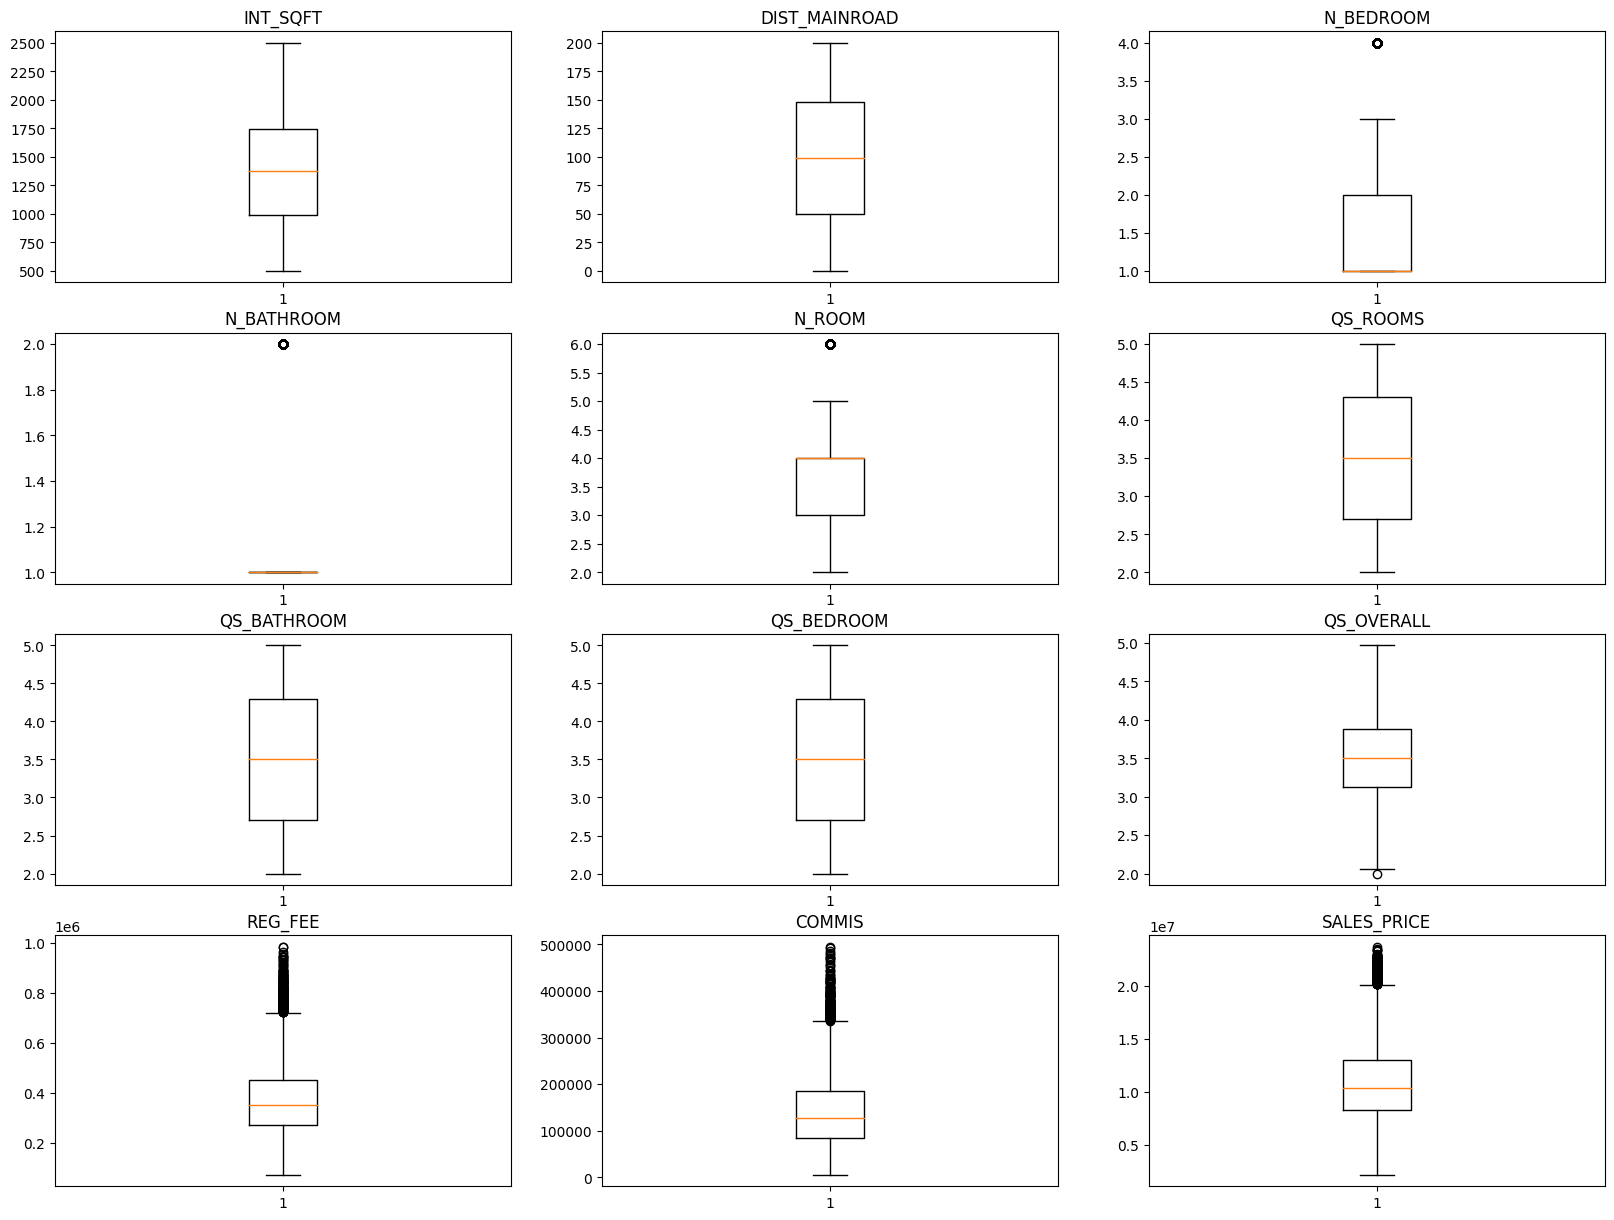

In [430]:
num_data = df.select_dtypes(include=['int64', 'float64'])
fig, ax = plt.subplots(4, 3, figsize=(20, 15))
ax = ax.flatten()
for i, col in enumerate(num_data.columns):
    ax[i].boxplot(num_data[col].dropna())
    ax[i].set_title(col)
plt.show()

In [431]:
#save cleaned data version for Dashboard implementing using power bi 
df.to_csv("cleaned_houseing_sale.csv")

Data Visualization

<BarContainer object of 7 artists>

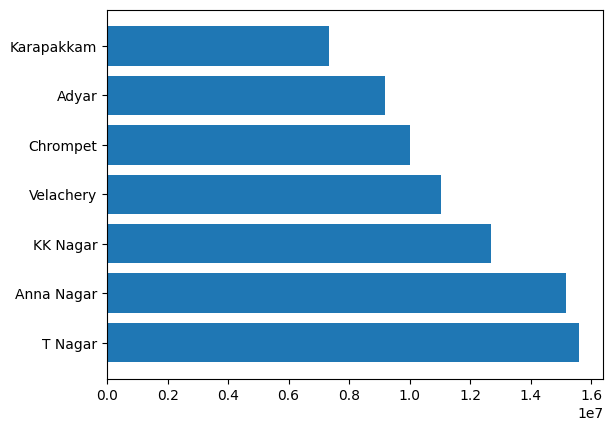

In [432]:
#heighest 10 areas in price
vs = df.groupby(by='AREA')['SALES_PRICE'].mean().sort_values(ascending=False)
plt.barh(vs.index,vs.values)

In [433]:
df['year'] = df['DATE_SALE'].dt.year

In [434]:
df['year'].value_counts()

year
2010    1340
2011    1300
2009    1122
2008     814
2012     651
2007     650
2013     364
2014     335
2006     253
2004     116
2005     107
2015      51
Name: count, dtype: int64

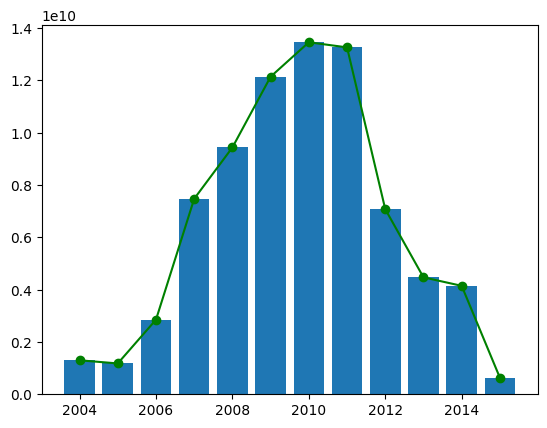

In [435]:
fig,ax = plt.subplots()
vs = df.groupby('year')['SALES_PRICE'].sum()
ax.bar(vs.index,vs.values)
ax.plot(vs.index,vs.values,color = 'green',marker= 'o')

Categorical Data 

In [436]:
catg_data = df.select_dtypes(include=['str'])
catg_data.head()

,PRT_ID,AREA,SALE_COND,PARK_FACIL,BUILDTYPE,UTILITY_AVAIL,STREET,MZZONE
0,P03210,Karapakkam,AbNormal,Yes,Commercial,AllPub,Paved,A
1,P09411,Anna Nagar,AbNormal,No,Commercial,AllPub,Gravel,RH
2,P01812,Adyar,AbNormal,Yes,Commercial,ELO,Gravel,RL
3,P05346,Velachery,Family,No,Others,NoSewr,Paved,I
4,P06210,Karapakkam,AbNormal,Yes,Others,AllPub,Gravel,C


In [437]:
label_encoded_data_columns = ['AREA','STREET','MZZONE','BUILDTYPE']
one_hot_encoded_coolumns = ['PARK_FACIL']
UTILITY_AVAIL_mapper = { 'AllPub':3, 'NoSeWa' : 2, 'NoSewr ': 1 , 'ELO' : 0 }
SALE_COND_mapper = { 'Normal Sale':4, 'AdjLand':3,'Family' : 2, 'Partial': 1 , 'AbNormal' : 0 }

In [438]:
for i in label_encoded_data_columns:
    le = LabelEncoder()
    catg_data[i] = le.fit_transform(catg_data[[i]])
for i in one_hot_encoded_coolumns:
    he = OneHotEncoder(sparse_output=False)
    catg_data[i]= he.fit_transform(catg_data[[i]])[:,0]
catg_data['UTILITY_AVAIL'] = catg_data['UTILITY_AVAIL'].map(UTILITY_AVAIL_mapper)
catg_data['SALE_COND'] = catg_data['SALE_COND'].map(SALE_COND_mapper)

Scale numeric data

In [439]:
cols = ['COMMIS','REG_FEE']
numeric_data = df[cols] 

In [440]:
ss = StandardScaler()
scaled_numeric_data = ss.fit_transform(numeric_data) 

In [441]:
numeric_data = pd.DataFrame(scaled_numeric_data,columns=numeric_data.columns)
numeric_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7103 entries, 0 to 7102
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   COMMIS   7103 non-null   float64
 1   REG_FEE  7103 non-null   float64
dtypes: float64(2)
memory usage: 111.1 KB


In [442]:
cols_to_drop = cols + list(catg_data.columns)
other = df.drop(cols_to_drop,axis = 1)  

In [443]:
other = other.reset_index(drop=True)
catg_data = catg_data.reset_index(drop=True)
numeric_data = numeric_data.reset_index(drop=True)
model_data = pd.concat([other,catg_data,numeric_data] ,axis = 1)
model_data

,INT_SQFT,DATE_SALE,DIST_MAINROAD,N_BEDROOM,N_BATHROOM,N_ROOM,DATE_BUILD,QS_ROOMS,QS_BATHROOM,QS_BEDROOM,...,PRT_ID,AREA,SALE_COND,PARK_FACIL,BUILDTYPE,UTILITY_AVAIL,STREET,MZZONE,COMMIS,REG_FEE
0,1004,2011-04-05,131,1.0,1.0,3,1967-05-15,4.0,3.9,4.9,...,P03210,4,0,0.0,0,3,2,0,0.042461,0.021298
1,1986,2006-12-19,26,2.0,1.0,5,1995-12-22,4.9,4.2,2.5,...,P09411,1,0,1.0,0,3,0,3,2.069226,2.678044
2,909,2012-04-02,70,1.0,1.0,3,1992-09-02,4.1,3.8,2.2,...,P01812,0,0,0.0,0,0,0,4,-0.621317,0.308512
3,1855,2010-03-13,14,3.0,2.0,5,1988-03-18,4.7,3.9,3.6,...,P05346,6,2,1.0,2,1,2,2,-0.812658,-0.144199
4,1226,2009-05-10,84,1.0,1.0,3,1979-10-13,3.0,2.5,4.1,...,P06210,4,0,0.0,2,3,0,1,-0.850477,-0.978156
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7098,598,2011-03-01,51,1.0,1.0,2,1962-01-15,3.0,2.2,2.4,...,P03834,4,3,1.0,2,0,1,5,-0.431576,-1.175482
7099,1897,2004-08-04,52,3.0,2.0,5,1995-11-04,3.6,4.5,3.3,...,P10000,6,2,0.0,2,2,1,3,0.818781,-0.215000
7100,1614,2006-08-25,152,2.0,1.0,4,1978-01-09,4.3,4.2,2.9,...,P09594,6,4,1.0,1,2,0,2,0.329726,-0.416547
7101,787,2009-03-08,40,1.0,1.0,2,1977-11-08,4.6,3.8,4.1,...,P06508,4,1,0.0,0,0,2,4,-0.278752,0.338258


In [444]:
model_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7103 entries, 0 to 7102
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   INT_SQFT       7103 non-null   int64         
 1   DATE_SALE      7103 non-null   datetime64[ns]
 2   DIST_MAINROAD  7103 non-null   int64         
 3   N_BEDROOM      7103 non-null   float64       
 4   N_BATHROOM     7103 non-null   float64       
 5   N_ROOM         7103 non-null   int64         
 6   DATE_BUILD     7103 non-null   datetime64[ns]
 7   QS_ROOMS       7103 non-null   float64       
 8   QS_BATHROOM    7103 non-null   float64       
 9   QS_BEDROOM     7103 non-null   float64       
 10  QS_OVERALL     7103 non-null   float64       
 11  SALES_PRICE    7103 non-null   int64         
 12  year           7103 non-null   int32         
 13  PRT_ID         7103 non-null   str           
 14  AREA           7103 non-null   int64         
 15  SALE_COND      7103 non-null   i

In [445]:
model_data.drop(['PRT_ID' , 'DATE_SALE','DATE_BUILD','year','INT_SQFT'],axis =1,inplace=True)
model_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7103 entries, 0 to 7102
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   DIST_MAINROAD  7103 non-null   int64  
 1   N_BEDROOM      7103 non-null   float64
 2   N_BATHROOM     7103 non-null   float64
 3   N_ROOM         7103 non-null   int64  
 4   QS_ROOMS       7103 non-null   float64
 5   QS_BATHROOM    7103 non-null   float64
 6   QS_BEDROOM     7103 non-null   float64
 7   QS_OVERALL     7103 non-null   float64
 8   SALES_PRICE    7103 non-null   int64  
 9   AREA           7103 non-null   int64  
 10  SALE_COND      7103 non-null   int64  
 11  PARK_FACIL     7103 non-null   float64
 12  BUILDTYPE      7103 non-null   int64  
 13  UTILITY_AVAIL  7103 non-null   int64  
 14  STREET         7103 non-null   int64  
 15  MZZONE         7103 non-null   int64  
 16  COMMIS         7103 non-null   float64
 17  REG_FEE        7103 non-null   float64
dtypes: float64(9), int6

In [446]:
model_data

,DIST_MAINROAD,N_BEDROOM,N_BATHROOM,N_ROOM,QS_ROOMS,QS_BATHROOM,QS_BEDROOM,QS_OVERALL,SALES_PRICE,AREA,SALE_COND,PARK_FACIL,BUILDTYPE,UTILITY_AVAIL,STREET,MZZONE,COMMIS,REG_FEE
0,131,1.0,1.0,3,4.0,3.9,4.9,4.330,7600000,4,0,0.0,0,3,2,0,0.042461,0.021298
1,26,2.0,1.0,5,4.9,4.2,2.5,3.765,21717770,1,0,1.0,0,3,0,3,2.069226,2.678044
2,70,1.0,1.0,3,4.1,3.8,2.2,3.090,13159200,0,0,0.0,0,0,0,4,-0.621317,0.308512
3,14,3.0,2.0,5,4.7,3.9,3.6,4.010,9630290,6,2,1.0,2,1,2,2,-0.812658,-0.144199
4,84,1.0,1.0,3,3.0,2.5,4.1,3.290,7406250,4,0,0.0,2,3,0,1,-0.850477,-0.978156
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7098,51,1.0,1.0,2,3.0,2.2,2.4,2.520,5353000,4,3,1.0,2,0,1,5,-0.431576,-1.175482
7099,52,3.0,2.0,5,3.6,4.5,3.3,3.920,10818480,6,2,0.0,2,2,1,3,0.818781,-0.215000
7100,152,2.0,1.0,4,4.3,4.2,2.9,3.840,8351410,6,4,1.0,1,2,0,2,0.329726,-0.416547
7101,40,1.0,1.0,2,4.6,3.8,4.1,4.160,8507000,4,1,0.0,0,0,2,4,-0.278752,0.338258


spliting data

In [447]:
y = model_data.SALES_PRICE
x = model_data.drop('SALES_PRICE',axis =1)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,shuffle=True,random_state=42) 

Principal Component Analysis.

In [ ]:
pca_model = PCA()
pca_model.fit(x_train)

PCA()

In [452]:
x_train.shape

(5327, 17)

Text(0, 0.5, 'variance')

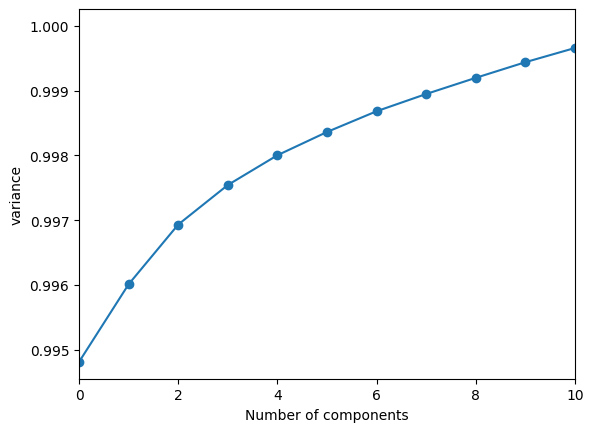

In [454]:
plt.plot(np.cumsum(pca_model.explained_variance_ratio_),marker= 'o')
plt.xlim(0,10)
plt.xlabel('Number of components')
plt.ylabel('variance')

In [455]:
pca_model = PCA(n_components=6)
x_train = pca_model.fit_transform(x_train)
x_test = pca_model.transform(x_test)

In [459]:
def evaluate(actual , predict):
    r2 = r2_score(actual,predict)
    MAE = mean_absolute_error(actual,predict)
    MSE = mean_squared_error(actual,predict)
    return MAE,MSE,r2

In [497]:
models ={
    'Linear Regression': LinearRegression(),
    'KNN' :KNeighborsRegressor(),
    'XGB':XGBRegressor(),
    'DT':DecisionTreeRegressor(),
    'RF':RandomForestRegressor()
}

In [498]:
model_names =[]
accuracy = []
for i , model_name in enumerate(list(models)):
    model = models[model_name]
    model.fit(x_train,y_train)
    pred =model.predict(x_test)

    MAE,MSE,r2 = evaluate(y_test,pred)
    
    model_names.append(model_name)
    accuracy.append(r2)

select algorithm

In [499]:
selection_algorithm_DF =  pd.DataFrame({'Model Name' : model_names , 'Accuracy' : accuracy}).sort_values(by ='Accuracy' ,ascending=False)
selection_algorithm_DF

,Model Name,Accuracy
4,RF,0.879420
2,XGB,0.857180
3,DT,0.761028
0,Linear Regression,0.710670
1,KNN,0.612719


select algorithm parameters

In [492]:
help(RandomForestRegressor)

Help on class RandomForestRegressor in module sklearn.ensemble._forest:

class RandomForestRegressor(ForestRegressor)
 |  RandomForestRegressor(n_estimators=100, *, criterion='squared_error', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=1.0, max_leaf_nodes=None, min_impurity_decrease=0.0, bootstrap=True, oob_score=False, n_jobs=None, random_state=None, verbose=0, warm_start=False, ccp_alpha=0.0, max_samples=None)
 |
 |  A random forest regressor.
 |
 |  A random forest is a meta estimator that fits a number of classifying
 |  decision trees on various sub-samples of the dataset and uses averaging
 |  to improve the predictive accuracy and control over-fitting.
 |  The sub-sample size is controlled with the `max_samples` parameter if
 |  `bootstrap=True` (default), otherwise the whole dataset is used to build
 |  each tree.
 |
 |  For a comparison between tree-based ensemble models see the example
 |  :ref:`sphx_glr_auto_examples_en

In [491]:
rf = RandomForestRegressor()
params ={
    'criterion' : ["squared_error", "absolute_error", "friedman_mse", "poisson"],
    'min_samples_split':[1,2,3,4],
    'min_samples_leaf':[1,2,3],
    'max_features' : ['sqrt', 'log2', None],
}
gs = GridSearchCV(rf , params , cv =5)
gs.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid={'criterion': ['squared_error', 'absolute_error',
                                       'friedman_mse', 'poisson'],
                         'max_features': ['sqrt', 'log2', None],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [1, 2, 3, 4]})

In [493]:
print("Best Params : ", gs.best_params_)
print("Best Score : ", gs.best_score_)

Best Params :  {'criterion': 'poisson', 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 3}
Best Score :  0.8704304686979387


In [500]:
rf_model = RandomForestRegressor(criterion = 'poisson', max_features = None, min_samples_leaf = 1, min_samples_split = 3)
rf_model.fit(x_train,y_train)
y_pred = rf_model.predict(x_test)

In [501]:
r2_score(y_pred,y_test)

0.8561616672889878